<a href="https://colab.research.google.com/github/VakeesanM/GPT1-Paper-Implementation/blob/main/GPT/Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from datasets import load_dataset
import time
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
CONTEXT_LEN = 128 # How many tokens the Model can look at once
EMBED_DIM = 300 # The Dimension of Vector Embeddings. GPT1 Actually used 768, but for performance reasons, I have decided to reduce it.
ATTN_HEAD = 12 # The Amount of Attention Heads at Mask Multi Head and Normal Multi Head Attention in each decoder.
# IMPORTANT: EMBED_DIM must be DIVISIBLE by ATTN_HEAD with no remainders.
DECODER_BLOCKS = 12 # The amount of Decoder Blocks in the Model.
TRAINING_EPOCHS = 15 # The Number of Epochs the Model will be trained for

In [ ]:

# Basic Attention Block
class Attention(nn.Module):
    def __init__(self, embed_size, d_k):
        super(Attention, self).__init__()
        self.d_k = d_k
        self.embed_size = embed_size

        self.values = nn.Linear(self.embed_size, self.d_k, bias=False)
        self.keys = nn.Linear(self.embed_size, self.d_k, bias=False)
        self.query = nn.Linear(self.embed_size, self.d_k, bias=False)
    def forward(self, x):

        Q = self.query(x)
        V = self.values(x)
        K = self.keys(x)


        _, S, _ = x.shape

        attn = (Q @ K.transpose(1,2)) / np.sqrt(self.d_k) # Q @ K.T / sqrt(d_k)

        #Masking
        attn_mask = torch.tril(torch.ones(size=(S, S), dtype=torch.bool)).to(device)
        attn = attn.masked_fill(~attn_mask, float('-inf'))

        #Turning Attn into Probablity
        attn = torch.softmax(attn, dim=-1)

        #Actual Attention Score
        scores = attn @ V

        return scores
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_size, heads):
    super(MultiHeadAttention, self).__init__()
    self.embed_size = embed_size
    self.d_k = self.embed_size // heads
    self.head_attn = nn.ModuleList()
    for i in range(heads):
      self.head_attn.add_module(f'Attention Head #{i}',Attention(self.embed_size, self.d_k))

    self.fc = nn.Linear(in_features=self.embed_size, out_features=self.embed_size)
  def forward(self, x):
    attn_outputs = []
    for head in self.head_attn:
      attn_outputs.append(head(x))

    x =  torch.cat(attn_outputs, dim=-1)
    x = self.fc(x)
    return x



In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self, embed_size):
    super(PositionalEncoding, self).__init__()
    self.embed_size = embed_size
  def forward(self, x):
    B, S, E = x.shape # (Batch_size, Seq, Embed)

    pos = torch.arange(S).unsqueeze(1) .to(device)
    i = torch.arange(E).unsqueeze(0).to(device)

    angle_rates = (pos / (10000 ** (2 * (i//2) / E))).to(device)

    pe = torch.zeros(S, E).to(device)
    pe[:, 0::2] = torch.sin(angle_rates[:, 0::2])
    pe[:, 1::2] = torch.cos(angle_rates[:, 1::2])

    x = x + pe.unsqueeze(0)
    return x



In [ ]:
class Decoder(nn.Module):
  def __init__(self, embed_size, heads):
    super(Decoder, self).__init__()
    self.embed_size = embed_size

    self.masked_multi_head_attn = MultiHeadAttention(embed_size, heads=heads)
    self.norm1 = nn.LayerNorm(normalized_shape=(self.embed_size))

    self.fc = nn.Sequential(
        nn.Linear(in_features=self.embed_size, out_features=self.embed_size*4),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(in_features=self.embed_size*4, out_features=self.embed_size)
    )
    self.norm2 = nn.LayerNorm(normalized_shape=(self.embed_size))

  def forward(self, x):

    shortcut = x
    x = self.masked_multi_head_attn(x)
    x = x + shortcut
    x = self.norm1(x)

    shortcut = x
    x = self.fc(x)
    x = x + shortcut
    x = self.norm2(x)
    return x


In [ ]:
class GPT1(nn.Module):
  def __init__(self, vocab_size=50257, embed_size=EMBED_DIM, heads=ATTN_HEAD, blocks=DECODER_BLOCKS):
    super(GPT1, self).__init__()
    self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_size)
    self.pos_emb = PositionalEncoding(embed_size)
    self.decoders = nn.ModuleList()
    for i in range(blocks):
      self.decoders.add_module(f"Decoder #{i+1}", Decoder(embed_size=embed_size, heads=heads))

    self.fc = nn.Sequential(
      nn.Linear(in_features=embed_size, out_features=1000),
      nn.LayerNorm(1000),
      nn.ReLU(),
      nn.Dropout(0.2),
      nn.Linear(in_features=1000, out_features=vocab_size)
      )
  def forward(self, x):
    x = self.embedding(x)
    x = self.pos_emb(x)
    for block in self.decoders:
      x = block(x)
    x = self.fc(x)
    #x = nn.Softmax(x). Unforuntely, the loss function for this model, Cross Entropy Loss, applies softmax, so we can't build in softmax into the model itself
    return x

#Loading and Processing Data

In [ ]:
ds = load_dataset("roneneldan/TinyStories", split="train[:12000]")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

In [ ]:
def tokenize_and_shift(example):
    token_ids = tokenizer(example["text"])["input_ids"]


    token_ids = token_ids[:CONTEXT_LEN + 1]

    x = token_ids[:CONTEXT_LEN]
    y = token_ids[1:CONTEXT_LEN + 1]

    return {"input_ids": x, "labels": y}

tokenized_ds = ds.map(tokenize_and_shift, remove_columns=ds.column_names)


In [ ]:
tokenized_ds = tokenized_ds.filter(lambda example: len(example["input_ids"]) >= CONTEXT_LEN)
tokenized_ds = tokenized_ds.filter(lambda example: len(example["labels"]) >= CONTEXT_LEN)


In [ ]:
tokenized_ds.set_format(type="torch", columns=["input_ids", "labels"])
loader = DataLoader(tokenized_ds, batch_size=32, shuffle=True)


# Model Training

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [ ]:
model = GPT1().to(device)
optim = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=TRAINING_EPOCHS, eta_min=3e-5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")


losses = []

start = time.time()
for epoch in range(TRAINING_EPOCHS):
  model.train()
  total_loss = 0
  for batch in loader:
    input = batch['input_ids'].to(device)
    target = batch['labels'].to(device)
    y_preds = model(input)
    loss = loss_fn(
        y_preds.view(-1, y_preds.size(-1)),
        target.view(-1)
    )
    optim.zero_grad()
    loss.backward()
    optim.step()
    total_loss += loss.item()
  losses.append(total_loss/len(loader))
  scheduler.step()
  print(f"Epoch: {epoch+1} | Training Loss: {losses[-1]:.5f} | Time: {(time.time()-start):.2f} ")

finish  = time.time()-start
min = finish//60
sec = finish % 60
print("========================================================================")
print(f"Training for {TRAINING_EPOCHS} took {min} Minutes and {sec:.2f} Seconds")



Total parameters: 78,683,357
Epoch: 1 | Training Loss: 4.26246 | Time: 236.82 
Epoch: 2 | Training Loss: 3.09180 | Time: 473.47 
Epoch: 3 | Training Loss: 2.74621 | Time: 710.74 
Epoch: 4 | Training Loss: 2.52577 | Time: 947.33 
Epoch: 5 | Training Loss: 2.34841 | Time: 1184.44 
Epoch: 6 | Training Loss: 2.19577 | Time: 1421.25 
Epoch: 7 | Training Loss: 2.05617 | Time: 1659.17 
Epoch: 8 | Training Loss: 1.92654 | Time: 1896.19 
Epoch: 9 | Training Loss: 1.80586 | Time: 2133.10 
Epoch: 10 | Training Loss: 1.69559 | Time: 2370.20 
Epoch: 11 | Training Loss: 1.59697 | Time: 2607.67 
Epoch: 12 | Training Loss: 1.51355 | Time: 2845.27 
Epoch: 13 | Training Loss: 1.44689 | Time: 3082.79 
Epoch: 14 | Training Loss: 1.39434 | Time: 3320.27 
Epoch: 15 | Training Loss: 1.35656 | Time: 3557.70 
Training for 15 took 59.0 Minutes and 17.70 Seconds


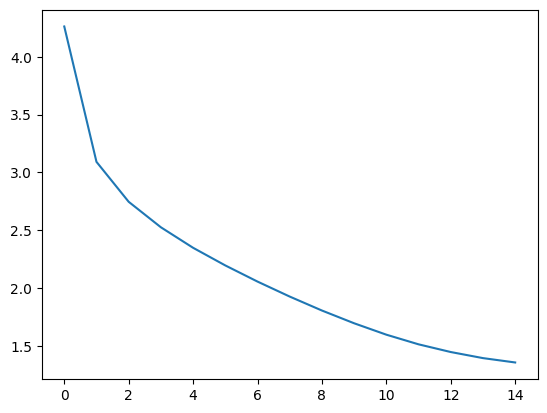

In [ ]:
plt.plot(losses)

In [ ]:
def Generate(model, text: str, max_len=20, temp=1):
  print(text, end="")
  softmax = nn.Softmax()
  token = tokenizer(text)['input_ids']
  for i in range(max_len):
    tensor = torch.tensor(token).unsqueeze(0)
    with torch.inference_mode():
      logitis = (model(tensor.to(device))[:, -1])/temp
      probs = softmax(logitis)
      output = torch.multinomial(probs, num_samples=1).item()
    print(tokenizer.decode(output), end="")
    token.append(output)



In [ ]:
torch.save(model.state_dict(), 'model.pt')

In [ ]:
text = "There was a dragon."

In [ ]:
Generate(model, text, max_len=25, temp=0.5)

There was a dragon. He was very happy and he loved to play in the park. One day, he saw a big tree and he wanted to